# Comparación de longitudes de full text
Analiza la evolución del contenido entre los pasos 4 (raw) y 5 (texto limpio) con un enfoque accionable similar al notebook de API Performance: cobertura, retención por cliente/formato y variación de longitud.

In [269]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 5)})

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from models.paper import Paper
from utils.intermediate_io import STEP4_FILE, STEP5_FILE, load_model_list

In [270]:
papers4 = load_model_list(STEP4_FILE, Paper)
papers5 = load_model_list(STEP5_FILE, Paper)

print(f"Step4: {len(papers4)} papers | Step5: {len(papers5)} papers")

Step4: 94 papers | Step5: 93 papers


In [271]:
def paper_id(p: Paper) -> str:
    return (p.doi or p.title).strip().lower()

def row_from_paper(p: Paper, step: int):
    if not p.full_text:
        return None
    return {
        "paper_id": paper_id(p),
        f"step{step}_format": p.full_text.format.value,
        f"step{step}_len": len(p.full_text.content),
        f"step{step}_client": p.ft_retrieved_by or "unknown",
    }

rows4 = [r for p in papers4 if (r := row_from_paper(p, 4))]
rows5 = [r for p in papers5 if (r := row_from_paper(p, 5))]

df4 = pd.DataFrame(rows4).set_index("paper_id")
df5 = pd.DataFrame(rows5).set_index("paper_id")

merged = df4.join(df5, how="outer").reset_index()

long_parts = []
for step in (4, 5):
    subset = merged[["paper_id", f"step{step}_len", f"step{step}_format", f"step{step}_client"]].dropna(subset=[f"step{step}_len"]).copy()
    subset.rename(columns={
        f"step{step}_len": "length",
        f"step{step}_format": "format",
        f"step{step}_client": "client",
    }, inplace=True)
    subset["step"] = step
    long_parts.append(subset)

lengths_long = pd.concat(long_parts, ignore_index=True)
merged.head()

,paper_id,step4_format,step4_len,step4_client,step5_format,step5_len,step5_client
0,10.1002/cmdc.202500244,xml,83719,europe_pmc,xml,33187.0,europe_pmc
1,10.1007/978-1-4613-1571-1,html,262151,openalex,html,8081.0,openalex
2,10.1007/978-1-4613-1571-1_1,html,371429,openalex,html,23865.0,openalex
3,10.1007/978-1-4613-1571-1_5,html,538518,openalex,html,45203.0,openalex
4,10.1007/978-3-031-50054-1_29,html,342527,openalex,html,68815.0,openalex


In [272]:
summary = (
    merged.dropna(subset=["step4_format", "step4_len"])
    .groupby("step4_format")
    .agg(
        n_step4=("step4_len", "count"),
        mean_len_step4=("step4_len", "mean"),
        median_len_step4=("step4_len", "median"),
        n_step5=("step5_len", "count"),
        mean_len_step5=("step5_len", "mean"),
        median_len_step5=("step5_len", "median"),
    )
    .assign(pct_with_step5=lambda df: df["n_step5"] / df["n_step4"] * 100)
    .sort_values("n_step4", ascending=False)
)
summary

,n_step4,mean_len_step4,median_len_step4,n_step5,mean_len_step5,median_len_step5,pct_with_step5
step4_format,,,,,,,
xml,43,1.419691e+05,133674.0,43,63257.720930,63415.0,100.0
plain,24,1.175503e+05,102992.5,24,115600.791667,101250.5,100.0
html,22,2.896300e+05,301170.0,22,35058.545455,15987.0,100.0
pdf,5,2.518910e+06,652900.0,4,28330.250000,19397.0,80.0


## Distribuciones y relaciones
Visualizaciones básicas para ver cómo cambian las longitudes por formato entre los pasos 4 (raw) y 5 (texto limpio).

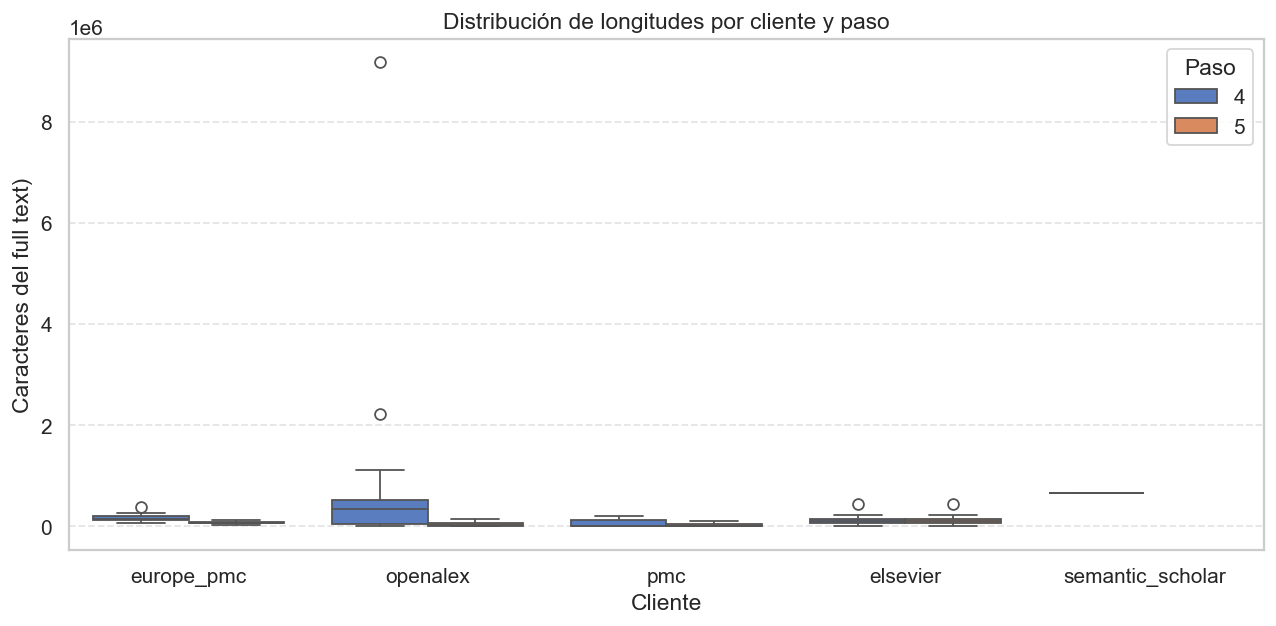

In [273]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=lengths_long,
    x="client",
    y="length",
    hue="step",
    palette="muted",
    ax=ax
)

ax.set_title("Distribución de longitudes por cliente y paso")
ax.set_xlabel("Cliente")
ax.set_ylabel("Caracteres del full text)")
ax.legend(title="Paso")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

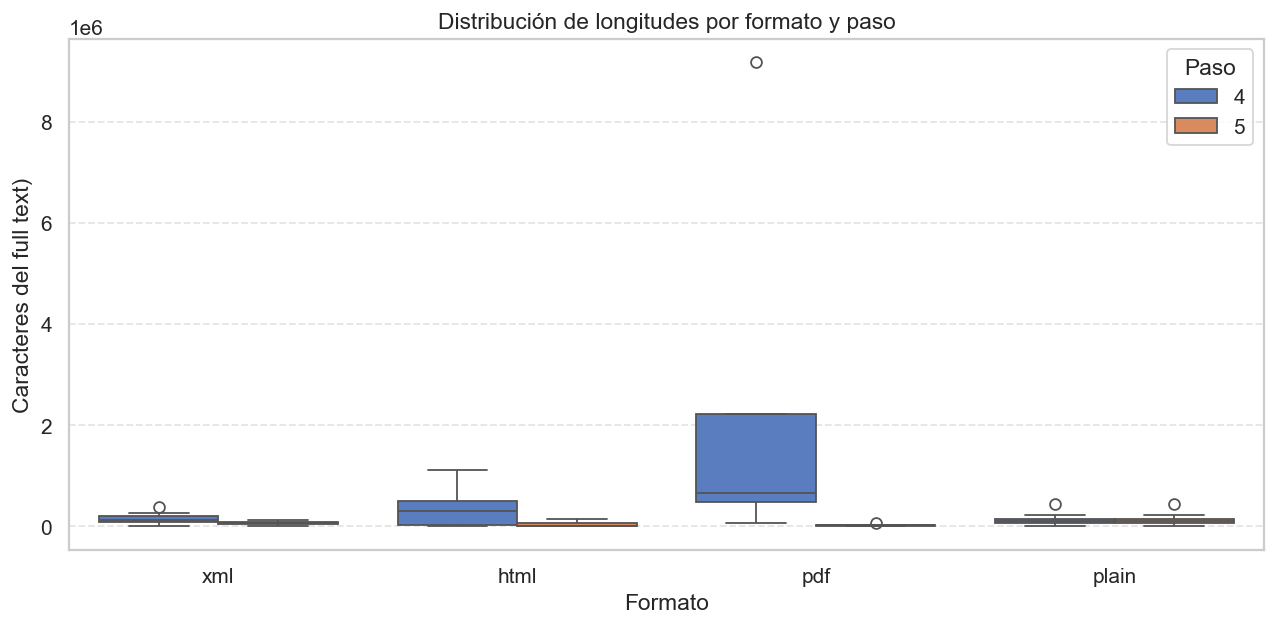

In [274]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=lengths_long,
    x="format",
    y="length",
    hue="step",
    palette="muted",
    ax=ax
)

ax.set_title("Distribución de longitudes por formato y paso")
ax.set_xlabel("Formato")
ax.set_ylabel("Caracteres del full text)")
ax.legend(title="Paso")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

In [275]:
both = merged.dropna(subset=["step4_len", "step5_len"]).copy()
both["delta_len"] = both["step5_len"] - both["step4_len"]
both["pct_delta"] = both["delta_len"] / both["step4_len"] * 100
delta_stats = {
    "count": len(both),
    "median_delta": both["delta_len"].median(),
    "mean_delta": both["delta_len"].mean(),
    "median_pct_delta": both["pct_delta"].median(),
    "mean_pct_delta": both["pct_delta"].mean(),
}
delta_stats

{'count': 93,
 'median_delta': np.float64(-61850.0),
 'mean_delta': np.float64(-224304.03225806452),
 'median_pct_delta': np.float64(-56.70228633602582),
 'mean_pct_delta': np.float64(-50.90078406490814)}

## Análisis por cliente de full text
Cuantifica cobertura y tamaño de los textos según el cliente que devolvió el full text (ft_retrieved_by).

In [276]:
client_overview = (
    lengths_long.assign(client=lengths_long["client"].fillna("unknown"))
    .groupby(["step", "client"], dropna=False)
    .agg(
        n=("length", "count"),
        mean_len=("length", "mean"),
        median_len=("length", "median"),
    )
    .sort_values(["step", "n"], ascending=False)
    .reset_index()
)
client_overview.head(20)

,step,client,n,mean_len,median_len
0,5,europe_pmc,32,73960.593750,70076.0
1,5,openalex,26,34023.423077,19397.0
2,5,elsevier,24,115600.791667,101250.5
3,5,pmc,11,32122.090909,3516.0
4,4,europe_pmc,32,165506.500000,153820.0
5,4,openalex,26,704365.653846,341358.0
6,4,elsevier,24,117550.333333,102992.5
7,4,pmc,11,73496.545455,10855.0
8,4,semantic_scholar,1,652900.000000,652900.0


In [277]:
client_format = (
    lengths_long.assign(client=lengths_long["client"].fillna("unknown"))
    .groupby(["step", "client", "format"], dropna=False)
    .agg(
        n=("length", "count"),
        mean_len=("length", "mean"),
        median_len=("length", "median"),
    )
    .sort_values(["step", "client", "n"], ascending=False)
    .reset_index()
)
client_format.head(20)

,step,client,format,n,mean_len,median_len
0,5,pmc,xml,11,3.212209e+04,3516.0
1,5,openalex,html,22,3.505855e+04,15987.0
2,5,openalex,pdf,4,2.833025e+04,19397.0
3,5,europe_pmc,xml,32,7.396059e+04,70076.0
4,5,elsevier,plain,24,1.156008e+05,101250.5
5,4,semantic_scholar,pdf,1,6.529000e+05,652900.0
6,4,pmc,xml,11,7.349655e+04,10855.0
7,4,openalex,html,22,2.896300e+05,301170.0
8,4,openalex,pdf,4,2.985412e+06,1348974.0
9,4,europe_pmc,xml,32,1.655065e+05,153820.0


## Caracteres antes y después por cliente y formato
Barras agrupadas con el número total de caracteres de full text antes (paso 4) y después (paso 5) de la extracción, desglosado por cliente y por formato.

,client,step,total_chars,n,avg_chars
0,elsevier,4,2821208.0,24,117550.333333
1,elsevier,5,2774419.0,24,115600.791667
2,europe_pmc,4,5296208.0,32,165506.500000
3,europe_pmc,5,2366739.0,32,73960.593750
4,openalex,4,18313507.0,26,704365.653846
5,openalex,5,884609.0,26,34023.423077
6,pmc,4,808462.0,11,73496.545455
7,pmc,5,353343.0,11,32122.090909
8,semantic_scholar,4,652900.0,1,652900.000000


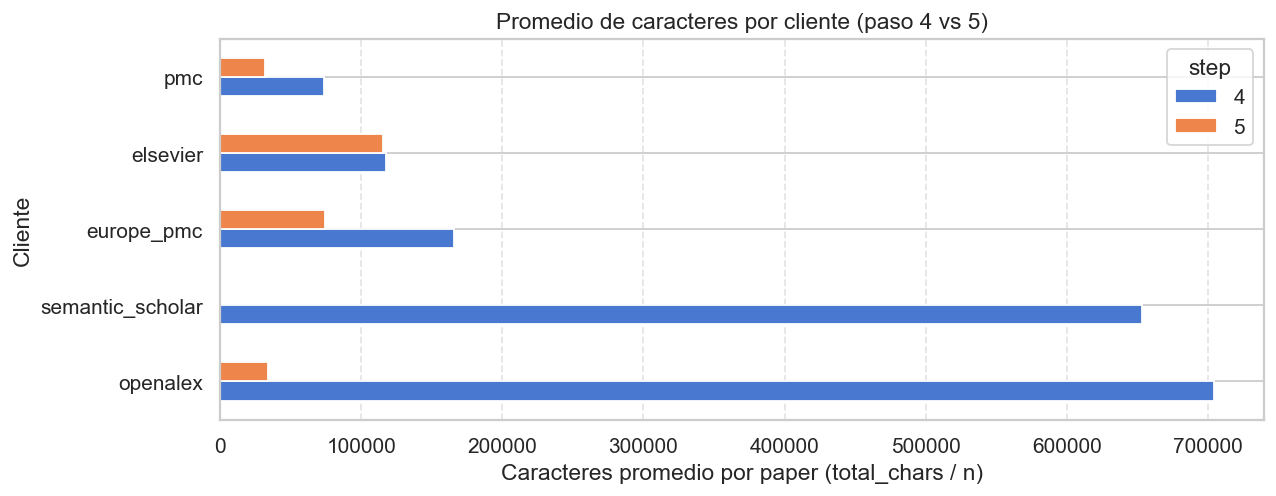

In [278]:
client_chars = (
    lengths_long.assign(client=lengths_long["client"].fillna("unknown"))
    .groupby(["client", "step"], dropna=False)
    .agg(total_chars=("length", "sum"), n=("paper_id", "count"))
    .reset_index()
)
client_chars["avg_chars"] = client_chars["total_chars"] / client_chars["n"]

client_chars_pivot = (
    client_chars.pivot(index="client", columns="step", values="avg_chars")
    .fillna(0)
    .sort_values(by=4, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(client_chars_pivot) * 0.3)))
client_chars_pivot[[4, 5]].plot(kind="barh", ax=ax)
ax.set_title("Promedio de caracteres por cliente (paso 4 vs 5)")
ax.set_xlabel("Caracteres promedio por paper (total_chars / n)")
ax.set_ylabel("Cliente")
ax.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

client_chars.head(10)

,format,step,total_chars,n,avg_chars
0,html,4,6371859.0,22,2.896300e+05
1,html,5,771288.0,22,3.505855e+04
2,pdf,4,12594548.0,5,2.518910e+06
3,pdf,5,113321.0,4,2.833025e+04
4,plain,4,2821208.0,24,1.175503e+05
5,plain,5,2774419.0,24,1.156008e+05
6,xml,4,6104670.0,43,1.419691e+05
7,xml,5,2720082.0,43,6.325772e+04


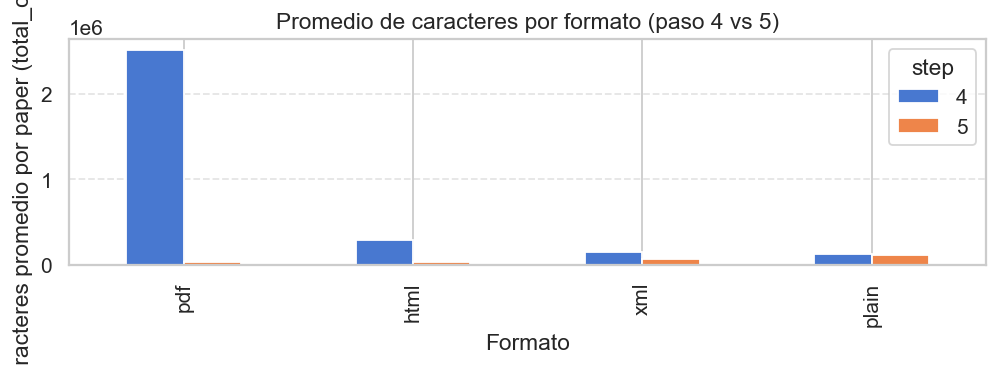

In [279]:
format_chars = (
    lengths_long.groupby(["format", "step"])
    .agg(total_chars=("length", "sum"), n=("paper_id", "count"))
    .reset_index()
 )

format_chars["avg_chars"] = format_chars["total_chars"] / format_chars["n"]

format_chars_pivot = (
    format_chars.pivot(index="format", columns="step", values="avg_chars")
    .fillna(0)
    .sort_values(by=4, ascending=False)
 )

fig, ax = plt.subplots(figsize=(8, max(3, len(format_chars_pivot) * 0.6)))
format_chars_pivot[[4, 5]].plot(kind="bar", ax=ax)
ax.set_title("Promedio de caracteres por formato (paso 4 vs 5)")
ax.set_ylabel("Caracteres promedio por paper (total_chars / n)")
ax.set_xlabel("Formato")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
format_chars

## Panel de métricas clave
Cobertura de extracción, variación de longitud y pérdidas por cliente/formato.

In [280]:
kpi = {
    "Cobertura step5 vs step4 (%)": round(df5.shape[0] / df4.shape[0] * 100, 2) if len(df4) else np.nan,
    "Mediana variación %": round(both["pct_delta"].median(), 2),
    "Media variación %": round(both["pct_delta"].mean(), 2),
    "Papers que pierden >20%": round((both["pct_delta"] < -20).mean() * 100, 2),
    "Papers que crecen >20%": round((both["pct_delta"] > 20).mean() * 100, 2),
}
pd.DataFrame.from_dict(kpi, orient="index", columns=["valor"])

,valor
Cobertura step5 vs step4 (%),98.94
Mediana variación %,-56.70
Media variación %,-50.90
Papers que pierden >20%,74.19
Papers que crecen >20%,0.00


## Retención por cliente
Cobertura de cada cliente de full text: cuántos textos llegan a paso 5 respecto a los disponibles en paso 4 (se muestran solo clientes con ≥5 textos en paso 4).

C:\Users\rebec\AppData\Local\Temp\ipykernel_11628\1213471325.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=retencion_cliente.reset_index(), y="step4_client", x="pct_step5", palette="crest", ax=ax)


,step4_client,n_step4,n_step5,pct_step5
0,elsevier,24,24,100.0
1,europe_pmc,32,32,100.0
2,openalex,26,26,100.0
3,pmc,11,11,100.0


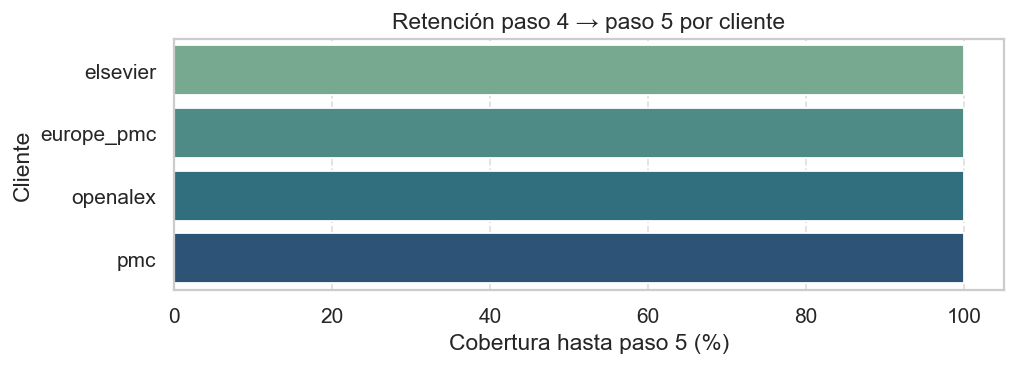

In [281]:
retencion_cliente = (
    merged[merged["step4_len"].notna()]
    .groupby("step4_client")
    .agg(n_step4=("step4_len", "count"), n_step5=("step5_len", "count"))
)
retencion_cliente["pct_step5"] = retencion_cliente["n_step5"] / retencion_cliente["n_step4"] * 100
retencion_cliente = retencion_cliente[retencion_cliente["n_step4"] >= 5].sort_values("pct_step5")

fig, ax = plt.subplots(figsize=(8, max(3, len(retencion_cliente) * 0.35)))
sns.barplot(data=retencion_cliente.reset_index(), y="step4_client", x="pct_step5", palette="crest", ax=ax)
ax.set_xlabel("Cobertura hasta paso 5 (%)")
ax.set_ylabel("Cliente")
ax.set_title("Retención paso 4 → paso 5 por cliente")
ax.grid(True, axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
retencion_cliente.reset_index().head(10)